In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [8]:
df_train = pd.read_csv("Datasets/UNSW_NB15_training-set.csv")
df_test  = pd.read_csv("Datasets/UNSW_NB15_testing-set.csv")

print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)

Train shape: (175341, 45)
Test shape : (82332, 45)


In [9]:
drop_cols = ['id', 'attack_cat']

df_train = df_train.drop(columns=drop_cols)
df_test  = df_test.drop(columns=drop_cols)

In [10]:
X_train = df_train.drop(columns=['label'])
y_train = df_train['label']

X_test  = df_test.drop(columns=['label'])
y_test  = df_test['label']

In [11]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

num_features = X_train.select_dtypes(include=['int64','float64']).columns
cat_features = X_train.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features),
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            min_frequency=50
        ), cat_features)
    ]
)

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

feature_selector = SelectFromModel(
    RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    threshold="median"   # keeps top 50% important features
)

In [13]:
final_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

In [14]:
from sklearn.pipeline import Pipeline

pipeline_fs = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('feature_selection', feature_selector),
    ('classifier', final_rf)
])

In [15]:
start_time = time.time()
pipeline_fs.fit(X_train, y_train)
training_time = time.time() - start_time

print("Training Time (s):", round(training_time, 2))

Training Time (s): 42.55


In [16]:
y_prob = pipeline_fs.predict_proba(X_test)[:, 1]

THRESHOLD = 0.4
y_pred = (y_prob > THRESHOLD).astype(int)

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8853179808579896
Precision: 0.835433100302815
Recall   : 0.985926056648725
F1 Score : 0.9044622078316301
ROC-AUC  : 0.9851318136940435


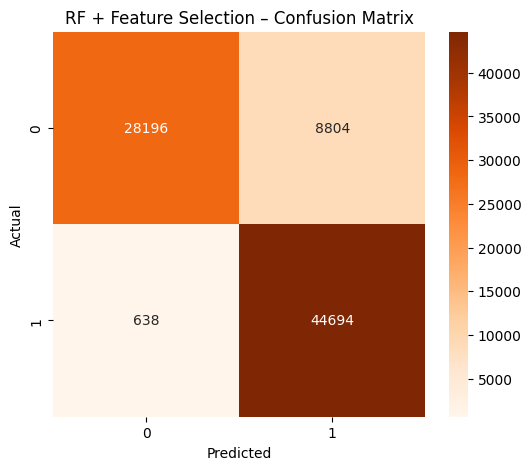

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("RF + Feature Selection – Confusion Matrix")
plt.show()

In [20]:
import joblib

joblib.dump(pipeline_fs, "rf_ids_model_with_feature_selection.joblib")
print("Model with feature selection saved")

Model with feature selection saved
